# Group 5: Exercises

**Chapter 2:** Exercises 5 and 6  
**Chapter 3:** Exercises 5, 10 and 15

*An Introduction to Statistical Learning with Applications in Python* (James, Witten, Hastie, Tibshirani & Taylor, 2023)

---

---

### Contents

| Exercise | Type | Dataset |
|---|---|---|
| 2.5 | Conceptual | — |
| 2.6 | Conceptual | — |
| 3.5 | Conceptual (algebra) | — |
| 3.10 | Applied | `Carseats` |
| 3.15 | Applied | `Boston` |

### How to Run it

> **To run this notebook:** `pip install ISLP` then *Kernel → Restart & Run All*.

In [1]:
# pip install ISLP

In [2]:
# Setup — run this cell first
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize, poly

%matplotlib inline
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 9})

print('Setup complete.')

Setup complete.


---
# Chapter 2, Exercise 5

> **Question.** What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

This exercise is purely conceptual, no computation is required.

## Answer

### Advantages of a more flexible approach

1. **Lower bias.** A flexible method can capture different shapes and patterns in the data. In contrast, a less flexible method such as linear regression assumes a specific relationship between the variables. If the real relationship is not linear, the less flexible method may not perform well.
2. **Better for complex relationships** Flexible methods are useful when the relationship between the predictors and the response is non-linear or when there are complex interactions between variables.
3. **It can discover structure that was not specified in advance(Can find patterns automatically).** With a flexible approach, we do not always need to specify the exact relationship beforehand. The model can discover patterns from the data.
4. **Better fit for complex data** When the actual relationship is complicated, a flexible model can usually fit the training data better and may produce better predictions.

### Disadvantages of a more flexible approach

1. **Higher variance.** A flexible model can be strongly affected by small changes in the training data. This can cause the model to fit the noise instead of the actual pattern, which is known as overfitting.
2. **Much harder to interpret.** Flexible models such as neural networks or boosted trees can be difficult to understand. It may not be easy to explain how a change in one predictor affects the response.
3. **Requires more data.** Because flexible models are more complex, they generally need more data to produce reliable results. With a small dataset, they can easily overfit.
4. **More tuning and more computation.** Flexible methods often have more parameters that need to be selected or adjusted. This can require techniques such as cross-validation and can increase computational cost.
5. **Training error is a misleading guide.** A flexible model may have a very low training error but still perform poorly on new data because it has learned the noise in the training set.

### When is a more flexible approach preferred?

- **$n$ is large and $p$ is relatively small** More data makes it easier to estimate a complex model without overfitting.
- **The true relationship is highly non-linear** If the real relationship is complex, flexibility can help the model capture it.
- **The goal is prediction, not inference** only $\hat{y} \approx y$ matters; interpretability is irrelevant.
- **The signal-to-noise ratio is high** (small $\operatorname{Var}(\varepsilon)$), so extra flexibility captures real structure rather than noise.

### When is a less flexible approach preferred?

- **$n$ is small, or $p$ is large relative to $n$** A flexible model may overfit when there are not enough observations.
- **There are many predictors compared with the number of observations** A less flexible model can help reduce the risk of overfitting.
- **The relationship is approximately linear** If the true relationship is already close to linear, a more complex model may not provide much additional benefit.
- **The goal is interpretation or inference** Less flexible models, such as linear regression, are easier to interpret and allow us to examine coefficients, standard errors, and p-values.
- **The error variance $\operatorname{Var}(\varepsilon)$ is large** with very noisy data a flexible method fits the noise, whereas a rigid method is protected by its own inflexibility.

### Summary


The main idea is that **flexibility involves a trade-off between bias and variance**. As a model becomes more flexible, its bias generally decreases because it can capture more complex patterns. However, its variance generally increases because it becomes more sensitive to the particular training data.

Therefore, the best choice depends on **the amount of data, the complexity of the true relationship, the amount of noise, and whether the main goal is prediction or interpretation**.

$$
\mathbb{E}\left(y_0 - \hat{f}(x_0)\right)^2 \;=\; \underbrace{\operatorname{Var}\!\left(\hat{f}(x_0)\right)}_{\text{rises with flexibility}} \;+\; \underbrace{\left[\operatorname{Bias}\!\left(\hat{f}(x_0)\right)\right]^2}_{\text{falls with flexibility}} \;+\; \underbrace{\operatorname{Var}(\varepsilon)}_{\text{irreducible}}
$$

**In simple terms:**
- **More flexible** lower bias but higher variance.
- **Less flexible** higher bias but lower variance.

Flexibility trades **bias for variance**. The right amount depends on the sample size, the true shape of $f$, the noise level, and whether the goal is to *predict* or to *explain*.

The trade-off is easier to see than to describe. The cell below reproduces the shape of Figure 2.12: the U-shaped test error curve against monotonically decreasing training error using a simulated example.

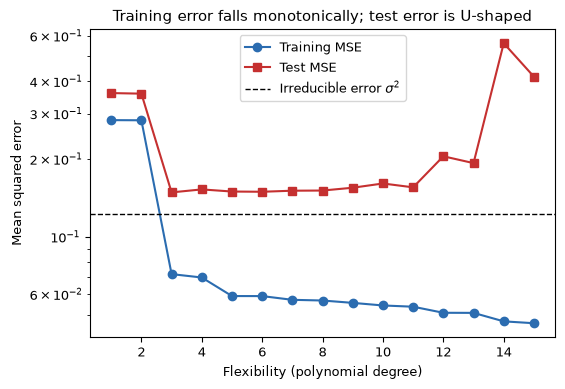

Best test MSE at degree 3; training MSE keeps falling to degree 15.


In [3]:
# Illustration of the bias-variance trade-off (not required by the exercise,
# but this is the figure worth being able to draw from memory in an exam)
rng = np.random.default_rng(1)

def true_f(x):
    return np.sin(2 * np.pi * x) + 0.5 * x

n, sigma = 40, 0.35
x_tr = np.sort(rng.uniform(0, 1, n)); y_tr = true_f(x_tr) + rng.normal(0, sigma, n)
x_te = np.sort(rng.uniform(0, 1, 400)); y_te = true_f(x_te) + rng.normal(0, sigma, 400)

degrees = range(1, 16)
train_mse, test_mse = [], []
for d in degrees:
    cf = np.polyfit(x_tr, y_tr, d)
    train_mse.append(np.mean((y_tr - np.polyval(cf, x_tr)) ** 2))
    test_mse.append(np.mean((y_te - np.polyval(cf, x_te)) ** 2))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(degrees, train_mse, 'o-', label='Training MSE', color='#2b6cb0')
ax.plot(degrees, test_mse, 's-', label='Test MSE', color='#c53030')
ax.axhline(sigma ** 2, ls='--', color='k', lw=1, label=r'Irreducible error $\sigma^2$')
ax.set_xlabel('Flexibility (polynomial degree)'); ax.set_ylabel('Mean squared error')
ax.set_title('Training error falls monotonically; test error is U-shaped')
ax.set_yscale('log'); ax.legend(); plt.show()

print(f"Best test MSE at degree {degrees[int(np.argmin(test_mse))]}; "
      f"training MSE keeps falling to degree {max(degrees)}.")

**Reading the plot.** Training MSE decreases monotonically a re flexible model always fits the training data better. Test MSE falls at first (bias reduction dominates), reaches a minimum, then rises sharply (variance dominates). Neither curve can drop below the dashed line, which is $\operatorname{Var}(\varepsilon)$.

Choosing the model with the lowest *training* error would select the most flexible model available and give the *worst* test performance. This is the single most important idea in the book.

---
# Chapter 2, Exercise 6

> **Question.** Describe the differences between a parametric and a non-parametric statistical learning approach. What are the advantages of a parametric approach to regression or classification (as opposed to a non-parametric approach)? What are its disadvantages?

This exercise is purely conceptual, no computation is required.

## Answer

### Differences between parametric and non-parametric approaches

1. **Parametric approaches make assumptions about the relationship.** A parametric method assumes that the relationship between the predictors and the response follows a particular mathematical form. For example, linear regression assumes that the relationship between the predictors and the response is linear.

2. **Non-parametric approaches make fewer assumptions.** A non-parametric method does not require us to assume a specific shape for the relationship. Instead, it uses the data to identify the pattern. Examples include K-nearest neighbors (KNN) and decision trees.

3. **Parametric approaches use a fixed number of parameters.** For example, in linear regression, we estimate parameters such as $\beta_0, \beta_1,$ and $\beta_2$. The number of parameters remains fixed even when more observations are added to the dataset.

4. **Non-parametric approaches are more flexible.** Their complexity can change depending on the data. This allows them to capture more complex relationships that may not be well represented by a simple mathematical model.

### Advantages of a parametric approach

1. **Simple and easy to interpret.** Parametric models usually have a relatively simple structure. For example, in linear regression, the coefficients can help us understand how a change in a predictor is associated with a change in the response.

2. **Requires less data.** Since the model makes assumptions about the relationship, it does not need as much data as some non-parametric methods to estimate the relationship.

3. **Faster and less computationally demanding.** Parametric models usually have a limited number of parameters, which makes them relatively quick to train and use.

4. **Less likely to overfit.** Since parametric models are less flexible, they are generally less likely to follow random noise in the training data, particularly when the dataset is small.

5. **Useful for statistical inference.** Parametric methods such as linear regression provide coefficients, standard errors, confidence intervals, and p-values. Therefore, they are useful when the purpose of the analysis is not only prediction but also understanding the relationship between variables.

### Disadvantages of a parametric approach

1. **It depends on assumptions.** The main weakness of a parametric approach is that it assumes a particular form for the relationship. For example, linear regression assumes that the relationship between the predictors and the response is linear.

2. **Can have high bias when the assumptions are wrong.** If the actual relationship in the data is very different from the assumed form, the model may not provide accurate predictions.

3. **Less flexible.** A parametric model may fail to capture complicated non-linear relationships or interactions between variables unless these are specifically included in the model.

4. **The model form must be selected in advance.** The researcher needs to decide which functional form is appropriate before fitting the model. If the wrong form is selected, the model may perform poorly.

### Summary

The main difference between the two approaches is the amount of assumptions they make. A **parametric approach** assumes a specific form for the relationship and estimates a fixed number of parameters. A **non-parametric approach** makes fewer assumptions and allows the data to determine the relationship.

A parametric approach is useful when the assumed relationship is reasonable, the dataset is relatively small, or when the main goal is to understand and interpret the relationships between variables. However, when the relationship is complex and there is enough data available, a non-parametric approach may provide better results because of its greater flexibility.

In simple terms:

> **Parametric methods provide simplicity and easier interpretation by making stronger assumptions, while non-parametric methods provide greater flexibility by making fewer assumptions.**


---
# Chapter 3, Exercise 5

> **Question.** Consider the fitted values from linear regression **without an intercept**, where $\hat{y}_i = x_i\hat{\beta}$ and $\hat{\beta}$ is given by equation (3.38). Show that we can write $\hat{y}_i = \sum_{i'=1}^{n} a_{i'} y_{i'}$, and identify $a_{i'}$.

This exercise is pure algebra, no computation is required. A numerical verification is included at the end as a check.

## Answer

### Setup

For simple linear regression **without an intercept**, the least squares estimate is equation (3.38):

$$
\hat{\beta} \;=\; \frac{\sum_{j=1}^{n} x_j y_j}{\sum_{j=1}^{n} x_j^{2}}
$$

and the $i$-th fitted value is $\hat{y}_i = x_i \hat{\beta}$.

### Derivation

Substitute $\hat{\beta}$ into the expression for $\hat{y}_i$, using $i'$ as the summation index in the numerator and a separate index $j$ in the denominator:

$$
\hat{y}_i \;=\; x_i \cdot \frac{\sum_{i'=1}^{n} x_{i'} y_{i'}}{\sum_{j=1}^{n} x_j^{2}}
$$

Both $x_i$ and the denominator $\sum_j x_j^2$ are constants with respect to the summation index $i'$, so they may be moved **inside** the sum:

$$
\hat{y}_i \;=\; \sum_{i'=1}^{n} \left( \frac{x_i \, x_{i'}}{\sum_{j=1}^{n} x_j^{2}} \right) y_{i'}
$$

This is exactly the required form $\hat{y}_i = \sum_{i'=1}^{n} a_{i'} y_{i'}$, with

$$
\boxed{\;a_{i'} \;=\; \frac{x_i \, x_{i'}}{\sum_{j=1}^{n} x_j^{2}}\;}
$$

### Two remarks worth adding

**1. The notation $a_{i'}$ is slightly misleading it depends on $i$ as well.** A more honest notation is

$$
a_{i i'} = \frac{x_i x_{i'}}{\sum_j x_j^2}
\qquad\text{so that}\qquad
\hat{y}_i = \sum_{i'} a_{i i'} \, y_{i'}
$$

Collecting these into an $n \times n$ matrix $\mathbf{A}$ gives $\hat{\mathbf{y}} = \mathbf{A}\mathbf{y}$. That matrix is the **hat matrix** $\mathbf{H} = \mathbf{x}(\mathbf{x}^{\top}\mathbf{x})^{-1}\mathbf{x}^{\top}$, specialised to a single predictor with no intercept. This exercise is the book quietly introducing the hat matrix, which reappears as **leverage** in Section 3.3.3: the leverage of observation $i$ is the diagonal element

$$
h_i \;=\; a_{ii} \;=\; \frac{x_i^{2}}{\sum_j x_j^{2}}
$$

**2. Why the result matters** this is the "interpret the result" part of the question:

- The fitted value at any point is a **weighted average of all $n$ observed responses**, including responses far away from $x_i$. Least squares is a *global* method: every observation influences every fitted value. This is precisely the property that local regression and splines in Chapter 7 are designed to give up.
- The weights $a_{i i'}$ depend **only on the predictor values $x$, never on $y$**. This makes least squares a *linear smoother*, and it is what allows closed-form expressions for $\operatorname{Var}(\hat{y})$, for leverage, and for the LOOCV shortcut formula in Chapter 5.
- The weight $a_{i i'}$ is large when **both** $x_i$ and $x_{i'}$ are far from zero. An observation with a large $|x|$ therefore pulls hard on the fit — this is the algebraic origin of **high-leverage points**.

**Sanity check.** If all predictor values are equal, then $a_{i'} = 1/n$ and $\hat{y}_i = \bar{y}$, the sample mean as it should be.

In [4]:
# Numerical verification of the derived formula
rng = np.random.default_rng(0)
n = 12
x = rng.normal(size=n)
y = 2 * x + rng.normal(size=n)

beta_hat = np.sum(x * y) / np.sum(x ** 2)      # equation (3.38)
y_hat_direct = x * beta_hat                     # direct: y_hat_i = x_i * beta_hat

A = np.outer(x, x) / np.sum(x ** 2)             # a_{i i'} = x_i x_{i'} / sum_j x_j^2
y_hat_via_A = A @ y                             # y_hat_i = sum_{i'} a_{i i'} y_{i'}

print("beta_hat = %.6f" % beta_hat)
print("Max absolute difference between the two routes: %.2e"
      % np.abs(y_hat_direct - y_hat_via_A).max())
print("Formulas agree:", np.allclose(y_hat_direct, y_hat_via_A))
print("\nLeverages h_i = a_ii (diagonal of A):")
print(np.round(np.diag(A), 4))
print("Sum of leverages = %.4f   (equals p = 1, as theory requires)" % np.trace(A))

beta_hat = 1.891468
Max absolute difference between the two routes: 2.22e-16
Formulas agree: True

Leverages h_i = a_ii (diagonal of A):
[0.0027 0.0029 0.0689 0.0018 0.0482 0.022  0.2855 0.1506 0.0831 0.2688
 0.0652 0.0003]
Sum of leverages = 1.0000   (equals p = 1, as theory requires)


The maximum discrepancy is at machine-precision level, confirming the derivation. The diagonal of $\mathbf{A}$ gives the leverages, and they sum to 1 — which is $p$, the number of parameters in this intercept-free model, exactly as the theory of the hat matrix requires.

---
# Chapter 3, Exercise 10 :The `Carseats` data

> **Question.** Fit a multiple regression model predicting `Sales` using `Price`, `Urban` and `US`; interpret the coefficients; write the model in equation form; test the coefficients; fit a reduced model; compare fits; obtain confidence intervals; and check for outliers and high-leverage observations.

`Sales` is measured in **thousands of units** sold at each of 400 stores; `Price` is in **dollars**.

In [5]:
Carseats = load_data('Carseats')
print("Shape:", Carseats.shape)
print("\nVariable types:")
print(Carseats.dtypes)
Carseats.head()

Shape: (400, 11)

Variable types:
Sales           float64
CompPrice         int64
Income            int64
Advertising       int64
Population        int64
Price             int64
ShelveLoc      category
Age               int64
Education         int64
Urban          category
US             category
dtype: object


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


## (a) Fit `Sales ~ Price + Urban + US`

In [6]:
y = Carseats['Sales']
X = MS(['Price', 'Urban', 'US']).fit_transform(Carseats)
m1 = sm.OLS(y, X).fit()

print(summarize(m1).round(4))
print("\nR^2 = %.4f | adjusted R^2 = %.4f | RSE = %.4f" %
      (m1.rsquared, m1.rsquared_adj, np.sqrt(m1.scale)))
print("F = %.2f on (%d, %d) df, p = %.3g" %
      (m1.fvalue, m1.df_model, m1.df_resid, m1.f_pvalue))

               coef  std err       t  P>|t|
intercept   13.0435    0.651  20.036  0.000
Price       -0.0545    0.005 -10.389  0.000
Urban[Yes]  -0.0219    0.272  -0.081  0.936
US[Yes]      1.2006    0.259   4.635  0.000

R^2 = 0.2393 | adjusted R^2 = 0.2335 | RSE = 2.4725
F = 41.52 on (3, 396) df, p = 2.39e-23


## (b) Interpretation of each coefficient

**Careful — two of the three predictors are qualitative.**

- **Intercept (13.0435).** The predicted sales for a rural, non-US store charging \$0 — about 13,043 units. **This is not a meaningful quantity.** `Price` ranges from \$24 to \$191 in the data, so \$0 is far outside the observed range and the value is pure extrapolation. Report it as a baseline, not as a finding.

- **`Price` (−0.0545).** Holding location fixed, a **\$1 increase in price is associated with a decrease of 0.0545 thousand units — about 55 fewer car seats sold** — on average. Highly significant ($t = -10.4$). The sign is what economics predicts.

- **`Urban[Yes]` (−0.0219).** `Urban` is qualitative, so a **dummy variable** has been created equal to 1 for urban stores and 0 for rural ones; **rural is the baseline**. The coefficient says urban stores sell about 22 fewer units than rural stores at the same price and US status. With $p = 0.936$ this is **statistically indistinguishable from zero** — there is no evidence that urban location matters at all.

- **`US[Yes]` (1.2006).** Also a dummy, with non-US as the baseline. Stores **in the US sell about 1,201 more units** than stores outside the US, holding price and urban status fixed. Highly significant ($t = 4.64$).

> **The trap the question warns about:** never write *"a one-unit increase in `Urban` decreases sales"*. `Urban` has no units — it is a category. The correct phrasing is always *"stores in category X sell N more/fewer units than stores in the baseline category, holding the other predictors fixed"*.

## (c) The model in equation form

$$
\texttt{Sales} = 13.0435 - 0.0545 \cdot \texttt{Price} - 0.0219 \cdot \texttt{Urban}_{\text{Yes}} + 1.2006 \cdot \texttt{US}_{\text{Yes}} + \varepsilon
$$

where

$$
\texttt{Urban}_{\text{Yes}} = \begin{cases} 1 & \text{if the store is urban} \\ 0 & \text{otherwise} \end{cases}
\qquad
\texttt{US}_{\text{Yes}} = \begin{cases} 1 & \text{if the store is in the US} \\ 0 & \text{otherwise} \end{cases}
$$

Written out as four separate fitted lines — all with the **same slope**, $-0.0545$, and different intercepts:

| Store type | Fitted equation |
|---|---|
| Rural, non-US | $\texttt{Sales} = 13.0435 - 0.0545 \cdot \texttt{Price}$ |
| Urban, non-US | $\texttt{Sales} = 13.0216 - 0.0545 \cdot \texttt{Price}$ |
| Rural, US | $\texttt{Sales} = 14.2441 - 0.0545 \cdot \texttt{Price}$ |
| Urban, US | $\texttt{Sales} = 14.2222 - 0.0545 \cdot \texttt{Price}$ |

Because the model contains no interaction terms, **the effect of price is assumed identical in all four groups** — the dummies shift the line up and down but never change its slope.

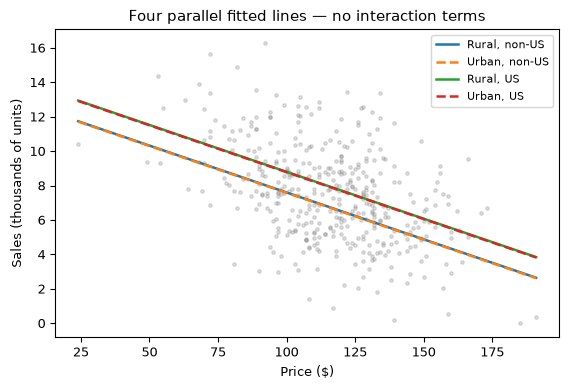

In [7]:
# The four fitted lines
b = m1.params
prices = np.linspace(Carseats['Price'].min(), Carseats['Price'].max(), 100)
fig, ax = plt.subplots(figsize=(6.5, 4))
for urban, us, style, lab in [(0, 0, '-', 'Rural, non-US'), (1, 0, '--', 'Urban, non-US'),
                              (0, 1, '-', 'Rural, US'),     (1, 1, '--', 'Urban, US')]:
    fit = b['intercept'] + b['Price'] * prices + b['Urban[Yes]'] * urban + b['US[Yes]'] * us
    ax.plot(prices, fit, style, label=lab, lw=1.8)
ax.scatter(Carseats['Price'], y, s=6, alpha=0.25, color='grey', zorder=0)
ax.set_xlabel('Price ($)'); ax.set_ylabel('Sales (thousands of units)')
ax.set_title('Four parallel fitted lines — no interaction terms')
ax.legend(fontsize=8); plt.show()

## (d) For which predictors can we reject $H_0: \beta_j = 0$?

We reject the null hypothesis for **`Price`** ($p < 0.001$) and **`US`** ($p < 0.001$).

We **cannot** reject it for **`Urban`** ($p = 0.936$) — there is no evidence that urban location is associated with sales once price and US status are accounted for.

## (e) Fit a smaller model using only the predictors with evidence of association

In [8]:
X2 = MS(['Price', 'US']).fit_transform(Carseats)
m2 = sm.OLS(y, X2).fit()

print(summarize(m2).round(4))
print("\nR^2 = %.4f | adjusted R^2 = %.4f | RSE = %.4f" %
      (m2.rsquared, m2.rsquared_adj, np.sqrt(m2.scale)))
print("F = %.2f on (%d, %d) df, p = %.3g" %
      (m2.fvalue, m2.df_model, m2.df_resid, m2.f_pvalue))

              coef  std err       t  P>|t|
intercept  13.0308    0.631  20.652    0.0
Price      -0.0545    0.005 -10.416    0.0
US[Yes]     1.1996    0.258   4.641    0.0

R^2 = 0.2393 | adjusted R^2 = 0.2354 | RSE = 2.4694
F = 62.43 on (2, 397) df, p = 2.66e-24


## (f) How well do the models in (a) and (e) fit the data?

In [9]:
comparison = pd.DataFrame({
    'model (a): Price + Urban + US': [m1.rsquared, m1.rsquared_adj, np.sqrt(m1.scale),
                                      m1.fvalue, int(m1.df_resid)],
    'model (e): Price + US':         [m2.rsquared, m2.rsquared_adj, np.sqrt(m2.scale),
                                      m2.fvalue, int(m2.df_resid)],
}, index=['R^2', 'adjusted R^2', 'RSE', 'F-statistic', 'residual df'])
print(comparison.round(4))

print("\nFormal comparison (does Urban add anything?):")
print(sm.stats.anova_lm(m2, m1).round(4))

              model (a): Price + Urban + US  model (e): Price + US
R^2                                  0.2393                 0.2393
adjusted R^2                         0.2335                 0.2354
RSE                                  2.4725                 2.4694
F-statistic                         41.5188                62.4311
residual df                        396.0000               397.0000

Formal comparison (does Urban add anything?):
   df_resid        ssr  df_diff  ss_diff       F  Pr(>F)
0     397.0  2420.8745      0.0      NaN     NaN     NaN
1     396.0  2420.8347      1.0   0.0398  0.0065  0.9357


In [10]:
# Context: how much better does a model with all the predictors do?
X_full = MS([c for c in Carseats.columns if c != 'Sales']).fit_transform(Carseats)
m_full = sm.OLS(y, X_full).fit()
print("Full model (all predictors): R^2 = %.4f, RSE = %.3f" %
      (m_full.rsquared, np.sqrt(m_full.scale)))
print("Model (e):                   R^2 = %.4f, RSE = %.3f" %
      (m2.rsquared, np.sqrt(m2.scale)))
print("\nSales: mean = %.2f, sd = %.2f" % (y.mean(), y.std()))

Full model (all predictors): R^2 = 0.8734, RSE = 1.019
Model (e):                   R^2 = 0.2393, RSE = 2.469

Sales: mean = 7.50, sd = 2.82


### Answer to (f)

| | Model (a) | Model (e) |
|---|---|---|
| $R^2$ | 0.2393 | 0.2393 |
| Adjusted $R^2$ | 0.2335 | **0.2354** |
| RSE | 2.4725 | **2.4694** |
| F-statistic | 41.52 | 62.43 |

**Two things to say, and both matter.**

**1. Model (e) is the better model.** It achieves the *same* $R^2$ with one fewer predictor. Adjusted $R^2$ is higher and RSE is lower, both because the penalty for the useless `Urban` term has been removed. The `anova_lm` comparison confirms this: dropping `Urban` increases RSS by only 0.0398 ($F = 0.0065$, $p = 0.936$), so the larger model is not a significant improvement. Prefer the smaller one.

**2. Neither model fits the data well.** $R^2 = 0.24$ means these predictors explain only **24% of the variation in sales**; 76% is unexplained. RSE $\approx 2.47$ thousand units against a mean `Sales` of 7.50 and a standard deviation of 2.82 — the typical prediction error is nearly as large as the raw variability we started with.

This is not a defect of linear regression; it is **omitted variables**. Fitting all available predictors gives $R^2 = 0.873$ and RSE $= 1.02$. The big missing driver is `ShelveLoc` (shelf position), along with `CompPrice`, `Advertising` and `Age`.

> A low $R^2$ can mean *"you left out the important predictors"*, not *"the model form is wrong"*. Distinguishing these two explanations is worth marks.

## (g) 95% confidence intervals for the coefficients in model (e)

In [11]:
ci = m2.conf_int()
ci.columns = ['2.5%', '97.5%']
ci['estimate'] = m2.params
print(ci[['estimate', '2.5%', '97.5%']].round(4))

           estimate     2.5%    97.5%
intercept   13.0308  11.7903  14.2713
Price       -0.0545  -0.0648  -0.0442
US[Yes]      1.1996   0.6915   1.7078


### Answer to (g)

| Term | Estimate | 2.5% | 97.5% |
|---|---|---|---|
| intercept | 13.0308 | 11.7903 | 14.2713 |
| `Price` | −0.0545 | **−0.0648** | **−0.0442** |
| `US[Yes]` | 1.1996 | **0.6915** | **1.7078** |

Neither slope interval contains zero, consistent with the p-values. In plain language: we are 95% confident that each extra dollar of price costs between **44 and 65 units** of sales, and that US stores sell between **692 and 1,708 more units** than non-US stores.

## (h) Is there evidence of outliers or high-leverage observations in model (e)?

In [12]:
infl = m2.get_influence()
stud  = infl.resid_studentized_external
lev   = infl.hat_matrix_diag
cooks = infl.cooks_distance[0]
n, p = X2.shape          # p includes the intercept column

print("n = %d, parameters (incl. intercept) = %d" % (n, p))
print("Average leverage p/n = %.4f   |   2x = %.4f   |   3x = %.4f"
      % (p / n, 2 * p / n, 3 * p / n))
print()
print("OUTLIERS")
print("  max |studentized residual| = %.3f" % np.abs(stud).max())
print("  count |resid| > 3   :", int((np.abs(stud) > 3).sum()))
print("  count |resid| > 2.5 :", int((np.abs(stud) > 2.5).sum()))
print("  count |resid| > 2   :", int((np.abs(stud) > 2).sum()),
      "  (expected by chance under normality: ~%.0f)" % (0.05 * n))
print()
print("LEVERAGE")
print("  max leverage = %.4f  (%.1fx the average)" % (lev.max(), lev.max() / (p / n)))
print("  count > 2p/n :", int((lev > 2 * p / n).sum()))
print("  count > 3p/n :", int((lev > 3 * p / n).sum()))
print()
print("INFLUENCE")
print("  max Cook's distance = %.4f" % cooks.max())

n = 400, parameters (incl. intercept) = 3
Average leverage p/n = 0.0075   |   2x = 0.0150   |   3x = 0.0225

OUTLIERS
  max |studentized residual| = 2.892
  count |resid| > 3   : 0
  count |resid| > 2.5 : 5
  count |resid| > 2   : 23   (expected by chance under normality: ~20)

LEVERAGE
  max leverage = 0.0433  (5.8x the average)
  count > 2p/n : 20
  count > 3p/n : 6

INFLUENCE
  max Cook's distance = 0.0261


In [13]:
print("Top 5 observations by |studentized residual|:")
o = np.argsort(-np.abs(stud))[:5]
print(pd.DataFrame({'obs': Carseats.index[o], 'Sales': y.values[o],
                    'fitted': m2.fittedvalues.values[o], 'stud_resid': stud[o],
                    'leverage': lev[o], 'cooks_D': cooks[o]}).round(4).to_string(index=False))

print("\nTop 5 observations by leverage:")
o = np.argsort(-lev)[:5]
print(pd.DataFrame({'obs': Carseats.index[o], 'Price': Carseats['Price'].values[o],
                    'US': Carseats['US'].values[o].astype(str), 'leverage': lev[o],
                    'stud_resid': stud[o], 'cooks_D': cooks[o]}).round(4).to_string(index=False))

print("\nPrice: min = %d, mean = %.2f, max = %d"
      % (Carseats['Price'].min(), Carseats['Price'].mean(), Carseats['Price'].max()))

Top 5 observations by |studentized residual|:
 obs  Sales  fitted  stud_resid  leverage  cooks_D
 376  16.27  9.2185      2.8915    0.0066   0.0183
  50   1.42  8.3469     -2.8358    0.0042   0.0112
  68  13.39  6.9304      2.6424    0.0052   0.0120
  25  14.90  8.5636      2.5997    0.0116   0.0261
 209   3.02  9.3274     -2.5816    0.0071   0.0157

Top 5 observations by leverage:
 obs  Price  US  leverage  stud_resid  cooks_D
  42     24  No    0.0433     -0.5350   0.0043
 174    185  No    0.0297     -1.2145   0.0150
 165    191 Yes    0.0286     -1.4215   0.0198
 125     49  No    0.0260     -0.4187   0.0016
 367     53  No    0.0237      1.7366   0.0243

Price: min = 24, mean = 115.80, max = 191


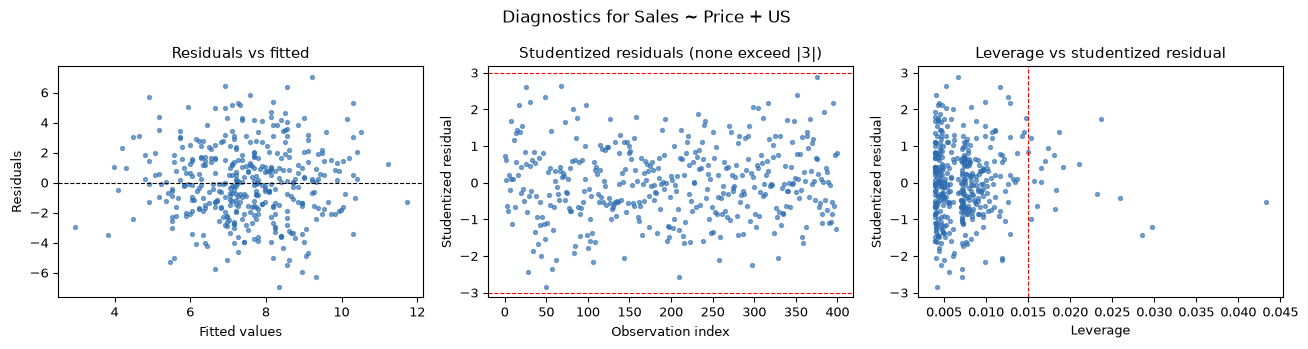

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].scatter(m2.fittedvalues, m2.resid, s=8, alpha=0.6, color='#2b6cb0')
axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs fitted')

axes[1].scatter(np.arange(n), stud, s=8, alpha=0.6, color='#2b6cb0')
for h in (-3, 3):
    axes[1].axhline(h, color='r', lw=0.8, ls='--')
axes[1].set_xlabel('Observation index'); axes[1].set_ylabel('Studentized residual')
axes[1].set_title('Studentized residuals (none exceed |3|)')

axes[2].scatter(lev, stud, s=8, alpha=0.6, color='#2b6cb0')
axes[2].axvline(2 * p / n, color='r', lw=0.8, ls='--')
axes[2].set_xlabel('Leverage'); axes[2].set_ylabel('Studentized residual')
axes[2].set_title('Leverage vs studentized residual')

fig.suptitle('Diagnostics for Sales ~ Price + US', fontsize=12)
fig.tight_layout(); plt.show()

### Answer to (h)

**Outliers (unusual $y$ given $x$): no.**

- The largest externally studentized residual in absolute value is **2.89** — **no observation exceeds the conventional threshold of 3**.
- 23 of 400 observations exceed $|2|$. Under normality we would expect about 20 by chance, so this is **entirely consistent with a normal error distribution**.
- The most extreme point (obs. 376) has actual sales of 16.27 against a fitted 9.22 — a large miss, but not beyond what random variation produces in a sample this size.

**High-leverage observations (unusual $x$): yes, several.**

- Average leverage is $(p+1)/n = 3/400 = 0.0075$; the usual flag is twice that, **0.015**.
- **20 observations exceed $2\times$** the average and **6 exceed $3\times$**.
- The highest leverage is **0.0433** (obs. 42), about **5.8× the average**. That store charges **\$24** — the minimum price in the data, far below the mean of \$115.80. It is extreme in the predictor space, exactly what leverage detects.

**Are any of them a problem? No.**

The maximum **Cook's distance is 0.0261**, far below any threshold of concern (values near 0.5 or 1 signal trouble). Crucially, the high-leverage observations have *small* residuals — obs. 42 has a studentized residual of only −0.54 — while the largest residuals occur at *ordinary* leverage. **Leverage and unusual response never coincide here**, so no single point is driving the fit.

> **Full-credit answers separate three ideas:** an **outlier** has an unusual $y$; a **high-leverage** point has an unusual $x$; an **influential** point is both, so that removing it changes the fit. Here: no outliers, some high-leverage points, nothing influential.

---
# Chapter 3, Exercise 15 — Predicting crime rate in `Boston`

> **Question.** Using the `Boston` data set, predict per capita crime rate using the other variables. (a) Fit a simple linear regression for each predictor. (b) Fit a multiple regression with all predictors. (c) Compare the two sets of coefficients. (d) Test for non-linear association using cubic fits.

Response: `crim`. Predictors: the other 12 variables.

## (a) Simple linear regression for each predictor

In [15]:
y_crim = Boston['crim']
predictors = [c for c in Boston.columns if c != 'crim']

rows, univariate = [], {}
for v in predictors:
    Xv = MS([v]).fit_transform(Boston)
    mv = sm.OLS(y_crim, Xv).fit()
    univariate[v] = mv.params.iloc[1]
    rows.append({'predictor': v, 'coefficient': mv.params.iloc[1],
                 'std_err': mv.bse.iloc[1], 't': mv.tvalues.iloc[1],
                 'p_value': mv.pvalues.iloc[1], 'R2': mv.rsquared})

simple = pd.DataFrame(rows).sort_values('R2', ascending=False)
simple['signif'] = np.where(simple.p_value < 0.001, '***',
                   np.where(simple.p_value < 0.01, '**',
                   np.where(simple.p_value < 0.05, '*', 'ns')))
simple.to_string(index=False, float_format=lambda z: f"{z:,.5g}")
print(simple.to_string(index=False, float_format=lambda z: f"{z:,.5g}"))

NameError: name 'Boston' is not defined

### Answer to (a)

**Eleven of the twelve predictors are significantly associated with crime rate** — all with p-values below $10^{-5}$. The single exception is **`chas`** ($p = 0.209$): whether a tract borders the Charles River tells us nothing about its crime rate.

| Predictor | Coefficient | $t$ | p-value | $R^2$ |
|---|---|---|---|---|
| `rad` | 0.6179 | 18.00 | $2.7 \times 10^{-56}$ | **0.391** |
| `tax` | 0.0297 | 16.10 | $2.4 \times 10^{-47}$ | 0.340 |
| `lstat` | 0.5488 | 11.49 | $2.7 \times 10^{-27}$ | 0.208 |
| `nox` | 31.2485 | 10.42 | $3.8 \times 10^{-23}$ | 0.177 |
| `indus` | 0.5098 | 9.99 | $1.5 \times 10^{-21}$ | 0.165 |
| `medv` | −0.3632 | −9.46 | $1.2 \times 10^{-19}$ | 0.151 |
| `dis` | −1.5509 | −9.21 | $8.5 \times 10^{-19}$ | 0.144 |
| `age` | 0.1078 | 8.46 | $2.9 \times 10^{-16}$ | 0.124 |
| `ptratio` | 1.1520 | 6.80 | $2.9 \times 10^{-11}$ | 0.084 |
| `rm` | −2.6841 | −5.04 | $6.3 \times 10^{-7}$ | 0.048 |
| `zn` | −0.0739 | −4.59 | $5.5 \times 10^{-6}$ | 0.040 |
| `chas` | −1.8928 | −1.26 | **0.209** | 0.003 |

But note how weak these models are individually. Even the best (`rad`) explains only **39%** of the variation, and most explain under 20%.

**The caveat from Exercise 2.10(d) applies directly here.** These fits are largely driven by the block of 132 suburbs with `rad = 24` and `tax = 666`, which contains all 18 suburbs with `crim > 20`. The scatterplots show two clusters rather than a linear trend, so **a significant p-value does not mean the linear model is a good description of the relationship.**

## (b) Multiple regression with all predictors

In [ ]:
X_all = MS(predictors).fit_transform(Boston)
m_mult = sm.OLS(y_crim, X_all).fit()

s = summarize(m_mult)
s['signif'] = np.where(s['P>|t|'] < 0.001, '***',
              np.where(s['P>|t|'] < 0.01, '**',
              np.where(s['P>|t|'] < 0.05, '*', 'ns')))
print(s.round(4))
print("\nR^2 = %.4f | adjusted R^2 = %.4f | RSE = %.4f" %
      (m_mult.rsquared, m_mult.rsquared_adj, np.sqrt(m_mult.scale)))
print("F = %.2f on (%d, %d) df, p = %.3g" %
      (m_mult.fvalue, m_mult.df_model, m_mult.df_resid, m_mult.f_pvalue))

### Answer to (b)

The F-statistic is **33.52 on (12, 493) df, $p = 2.0 \times 10^{-56}$** — overwhelming evidence that at least one predictor is associated with crime. The model explains $R^2 = 0.449$ of the variation, substantially more than any single predictor achieved in (a).

But at the 5% level we can reject $H_0: \beta_j = 0$ for only **four** predictors:

> **`rad`** ($p < 0.001$), **`dis`** ($p < 0.001$), **`medv`** ($p < 0.001$) and **`zn`** ($p = 0.015$).

`lstat` ($p = 0.067$) and `nox` ($p = 0.060$) are borderline. Everything else — `indus`, `chas`, `rm`, `age`, `tax`, `ptratio` — is not significant.

**Eleven predictors were significant alone; only four survive together.** Part (c) explains why.

## (c) Comparing the results of (a) and (b)

In [ ]:
compare = pd.DataFrame({'univariate': pd.Series(univariate),
                        'multiple': m_mult.params.drop('intercept')})
compare['sign_flip'] = np.sign(compare.univariate) != np.sign(compare.multiple)
print(compare.round(4).to_string())
print("\nNumber of sign flips: %d out of %d" % (compare.sign_flip.sum(), len(compare)))
print("Correlation between the two coefficient vectors: %.3f"
      % compare.univariate.corr(compare.multiple))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
u, mlt = compare.univariate, compare.multiple

axes[0].scatter(u, mlt, s=35, color='#2b6cb0')
for v in predictors:
    axes[0].annotate(v, (u[v], mlt[v]), fontsize=7.5, xytext=(4, 4),
                     textcoords='offset points')
axes[0].axhline(0, color='k', lw=0.6); axes[0].axvline(0, color='k', lw=0.6)
axes[0].set_xlabel('Univariate (simple regression) coefficient')
axes[0].set_ylabel('Multiple regression coefficient')
axes[0].set_title('All predictors — nox dominates the scale')

keep = [v for v in predictors if v != 'nox']
axes[1].scatter(u[keep], mlt[keep], s=35, color='#c53030')
for v in keep:
    axes[1].annotate(v, (u[v], mlt[v]), fontsize=7.5, xytext=(4, 4),
                     textcoords='offset points')
axes[1].axhline(0, color='k', lw=0.6); axes[1].axvline(0, color='k', lw=0.6)
axes[1].set_xlabel('Univariate coefficient'); axes[1].set_ylabel('Multiple coefficient')
axes[1].set_title('nox removed — the remaining points made visible')

fig.suptitle('Simple vs multiple regression coefficients', fontsize=12)
fig.tight_layout(); plt.show()

In [ ]:
# Why the coefficients change: the predictors are heavily collinear
Boston[['nox', 'indus', 'dis', 'age', 'tax', 'rad', 'lstat', 'medv']].corr().round(2)

### Answer to (c)

| Predictor | Univariate | Multiple | Sign flip? |
|---|---|---|---|
| `zn` | −0.0739 | +0.0457 | **yes** |
| `indus` | +0.5098 | −0.0584 | **yes** |
| `chas` | −1.8928 | −0.8254 | no |
| `nox` | **+31.2485** | **−9.9576** | **yes** |
| `rm` | −2.6841 | +0.6289 | **yes** |
| `age` | +0.1078 | −0.0008 | **yes** |
| `dis` | −1.5509 | −1.0122 | no |
| `rad` | +0.6179 | +0.6125 | no |
| `tax` | +0.0297 | −0.0038 | **yes** |
| `ptratio` | +1.1520 | −0.3041 | **yes** |
| `lstat` | +0.5488 | +0.1388 | no |
| `medv` | −0.3632 | −0.2201 | no |

**The points do not lie on a 45° line.** Seven of the twelve coefficients **change sign**, and the correlation between the two coefficient vectors is **−0.97**.

**`nox` is the dramatic case.** In simple regression its coefficient is **+31.25**; in multiple regression it is **−9.96**. In the plot it sits alone on the far right, which is why the second panel repeats the plot without it.

### Why does this happen?

Because the predictors are heavily collinear:

| | `nox` | `indus` | `dis` | `age` | `tax` | `rad` |
|---|---|---|---|---|---|---|
| `nox` | 1.00 | 0.76 | −0.77 | 0.73 | 0.67 | 0.61 |
| `indus` | 0.76 | 1.00 | −0.71 | 0.64 | 0.72 | 0.60 |
| `tax` | 0.67 | 0.72 | −0.53 | 0.51 | 1.00 | **0.91** |

The two regressions answer **different questions**:

- **Simple regression asks:** *ignoring everything else, is `nox` associated with crime?* Answer: strongly — because polluted tracts are the industrial inner-city tracts that also have high crime. `nox` acts as a **proxy** for the whole urban syndrome.
- **Multiple regression asks:** *holding all eleven other variables fixed, does `nox` add anything?* Answer: no. Once highway access, distance to employment centres and median home value are known, pollution contributes nothing further. The apparent effect in (a) was **confounding**, not a `nox` effect.

The `tax`/`rad` pair ($r = 0.91$) is the clearest collinearity problem. They carry nearly identical information, so the multiple regression keeps only one: it keeps `rad` ($t = 7.00$) and discards `tax` ($t = -0.73$). **Which one it keeps is close to arbitrary** — this instability is exactly what motivates ridge and lasso in Chapter 6.

> This exercise is the book's most vivid demonstration of the point made in Section 3.3.3: **a predictor significant on its own can be worthless in the presence of correlated predictors, and vice versa.**

## (d) Is there evidence of non-linear association?

For each predictor $X$ we fit

$$
Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \varepsilon
$$

and examine the p-values on the quadratic and cubic terms.

In [ ]:
rows = []
for v in predictors:
    if Boston[v].nunique() <= 2:          # chas is binary: a polynomial is not identifiable
        rows.append({'predictor': v, 'p_linear': np.nan, 'p_quadratic': np.nan,
                     'p_cubic': np.nan, 'R2_linear': np.nan, 'R2_cubic': np.nan,
                     'verdict': 'binary - not applicable'})
        continue
    m_poly = sm.OLS(y_crim, MS([poly(v, degree=3)]).fit_transform(Boston)).fit()
    m_lin  = sm.OLS(y_crim, MS([v]).fit_transform(Boston)).fit()
    p_lin, p_quad, p_cub = m_poly.pvalues.iloc[1:4]
    rows.append({'predictor': v, 'p_linear': p_lin, 'p_quadratic': p_quad,
                 'p_cubic': p_cub, 'R2_linear': m_lin.rsquared,
                 'R2_cubic': m_poly.rsquared,
                 'verdict': ('cubic significant' if p_cub < 0.05 else
                             'quadratic only' if p_quad < 0.05 else 'linear adequate')})

nonlin = pd.DataFrame(rows).sort_values('R2_cubic', ascending=False)
print(nonlin.to_string(index=False, float_format=lambda z: f"{z:,.4g}"))

In [ ]:
# The four predictors with the biggest gain from adding polynomial terms
top = nonlin.dropna().nlargest(4, 'R2_cubic')['predictor'].tolist()
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, v in zip(axes, top):
    ax.scatter(Boston[v], y_crim, s=6, alpha=0.4, color='grey')
    xs = np.linspace(Boston[v].min(), Boston[v].max(), 200)
    cf3 = np.polyfit(Boston[v], y_crim, 3)
    cf1 = np.polyfit(Boston[v], y_crim, 1)
    ax.plot(xs, np.polyval(cf1, xs), 'b--', lw=1.5, label='linear')
    ax.plot(xs, np.polyval(cf3, xs), 'r-', lw=1.8, label='cubic')
    ax.set_xlabel(v); ax.set_ylabel('crim')
    r2l = nonlin.set_index('predictor').loc[v, 'R2_linear']
    r2c = nonlin.set_index('predictor').loc[v, 'R2_cubic']
    ax.set_title(f'{v}:  $R^2$  {r2l:.3f} → {r2c:.3f}', fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle('Linear vs cubic fits for the four predictors with the largest gain', fontsize=12)
fig.tight_layout(); plt.show()

### Answer to (d)

**Yes — there is clear evidence of non-linearity for most predictors.**

| Predictor | p (quadratic) | p (cubic) | $R^2$ linear | $R^2$ cubic | Verdict |
|---|---|---|---|---|---|
| `medv` | $2.9\times10^{-35}$ | $1.0\times10^{-12}$ | 0.151 | **0.420** | strong cubic |
| `nox` | $7.7\times10^{-5}$ | $7.0\times10^{-16}$ | 0.177 | 0.297 | strong cubic |
| `dis` | $7.9\times10^{-14}$ | $1.1\times10^{-8}$ | 0.144 | 0.278 | strong cubic |
| `indus` | 0.0011 | $1.2\times10^{-12}$ | 0.165 | 0.260 | strong cubic |
| `age` | $2.3\times10^{-6}$ | 0.0067 | 0.124 | 0.174 | cubic |
| `ptratio` | 0.0024 | 0.0063 | 0.084 | 0.114 | cubic |
| `rad` | 0.0091 | 0.482 | 0.391 | 0.400 | quadratic only |
| `tax` | $3.7\times10^{-6}$ | 0.244 | 0.340 | 0.369 | quadratic only |
| `lstat` | 0.038 | 0.130 | 0.208 | 0.218 | quadratic only |
| `zn` | 0.0044 | 0.230 | 0.040 | 0.058 | quadratic only |
| `rm` | 0.0015 | 0.509 | 0.048 | 0.068 | quadratic only |
| `chas` | — | — | — | — | binary; not applicable |

- **Six predictors** (`medv`, `nox`, `dis`, `indus`, `age`, `ptratio`) have a **significant cubic term**, so a straight line is definitely the wrong shape.
- **Five more** (`rad`, `tax`, `lstat`, `zn`, `rm`) have a significant quadratic term but not a cubic one — curvature, but not an S-shape.
- **`medv` is the most striking**: $R^2$ rises from **0.151** to **0.420**. Nearly tripling the explained variance means the linear model was badly mis-specified. Crime falls steeply as `medv` rises through the low range, then flattens.
- **`chas`** takes only two values, so `chas`, `chas²` and `chas³` are the same variable and the polynomial is not identifiable.

### Two cautions worth including

1. **A significant cubic term is not proof of a genuine cubic relationship.** Polynomials fit flexibly and behave badly at the boundaries of the data. For `rad` and `tax`, the apparent curvature is almost certainly an artefact of the two-cluster structure identified in part (a) — the polynomial is bending to reach a clump of points, not tracing a smooth curve.
2. **This is twelve simultaneous hypothesis tests.** At $\alpha = 0.05$ we would expect roughly 0.6 false positives by chance. The very small p-values here survive a Bonferroni correction easily, but the general issue is Chapter 13's.

---
# Where this leads

These five exercises point directly at the next four chapters:

| Problem encountered | Chapter that solves it |
|---|---|
| Polynomials behave badly at the boundaries (3.15d) | **Ch. 7** — splines and GAMs add flexibility by placing knots, not by raising the degree |
| `rad`/`tax` collinearity makes coefficients arbitrary (3.15c) | **Ch. 6** — ridge and lasso stabilise correlated predictors instead of choosing between them at random |
| The two-cluster structure in `Boston` (2.10d, 3.15a) | **Ch. 8** — trees handle this natively, with no polynomial gymnastics |
| Twelve simultaneous tests (3.15d) | **Ch. 13** — Holm and Benjamini–Hochberg |
| How to choose any tuning parameter | **Ch. 5** — cross-validation |

---

### Exporting this notebook to PDF for submission

```bash
jupyter nbconvert --to webpdf --allow-chromium-download solutions.ipynb
```

Use `--to webpdf` rather than `--to pdf` — the latter requires a full LaTeX installation and often breaks on wide DataFrame output. Failing that, open the notebook in a browser and print to PDF.

**Before exporting:** *Kernel → Restart & Run All*, then check that every cell has run in order (cell numbers 1, 2, 3, …). Markers notice out-of-order execution counts, and they are a common source of lost marks.